In [1]:
from backend.Agents.PDF_create import 

SyntaxError: invalid syntax (3619130629.py, line 1)

In [7]:
import nltk

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\soumi\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\soumi\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\soumi\AppData\Roaming\nltk_data...


True

In [15]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from selenium import webdriver
from rank_bm25 import BM25Okapi
from openai import OpenAI
from sklearn.metrics.pairwise import cosine_similarity
import requests
import trafilatura
from dotenv import load_dotenv
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from langchain_text_splitters import RecursiveCharacterTextSplitter

load_dotenv()
client = OpenAI()

def get_words_list(text: str):
    stop_words = set(ENGLISH_STOP_WORDS)
    lemmatizer = WordNetLemmatizer()

    # Fix merged words (camelCase → split)
    text = re.sub(r'([a-z])([A-Z])', r'\1 \2', text)

    # Separate numbers from words
    text = re.sub(r'(\d+)', r' \1 ', text)

    # Lowercase
    text = text.lower()

    # Extract words
    words = re.findall(r'\b[a-zA-Z]+\b', text)

    # Remove stopwords + lemmatize
    final_words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words and len(word) > 2
    ]

    return final_words

def keyword_score(sentence : str, body:str):
    sentence_list=get_words_list(sentence)

    body_word_list=get_words_list(body)
    sentence_set=set(sentence_list)
    score=0
    for a in body_word_list:
        if any(a.startswith(b) or b.startswith(a) for b in sentence_set):
            #checking prefix between a & b
            score+=1  

    final_score=score/len(body_word_list)

    return final_score 

def filter_list(query, A_dict_list):
    filtered_list=[]

    for a_dict in A_dict_list:

        body=a_dict.get('body')
        title=a_dict.get('title')

        score1=keyword_score(query, body)
        score2=keyword_score(query, title)

        score=0.95*score1+0.05*score2
        a_dict['keyword_score']=score
        
        if score>0.10:
            filtered_list.append(a_dict)

    filtered_list=sorted(filtered_list, key=lambda x: x['keyword_score'], reverse=True)
    return filtered_list


def get_html_content(url):
    headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
                  "(KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"}
    html=requests.get(url, headers=headers).text
    content=trafilatura.extract(html)

    if not content or len(content) < 150:
        driver = webdriver.Chrome()
        driver.get(url)
        html = driver.page_source
        content=trafilatura.extract(html)
        driver.quit()
    return str(content)

def chunk_text(text):
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=300,       
        chunk_overlap=50,      
        separators=["\n\n", "\n", ".", " "]
    )
    
    chunks = splitter.split_text(text)
    return chunks


def bm25_retrieve(text:str, query:str):
    chunks = chunk_text(text)
    
    tokenized_corpus = [get_words_list(s) for s in chunks]
    
    bm25 = BM25Okapi(tokenized_corpus)
    
    tokenized_query = get_words_list(query)
    
    scores = bm25.get_scores(tokenized_query)
    
    # Rank sentences
    ranked = sorted(
        zip(chunks, scores),
        key=lambda x: x[1],
        reverse=True
    )
    ranked=ranked[:40]
    ranked_sentences=[sentence[0] for sentence in ranked]
    return ranked_sentences


def get_webpage(query:str, A_dict_list: list):

    filtered_list=filter_list(query=query, A_dict_list=A_dict_list)

    if len(filtered_list)>4:
        filtered_list=filtered_list[:4]

    web_content_chunks={}
    
    for filter in filtered_list:
        semantic_similar_sentence=[]
        website=str(filter.get('href'))
        
        content=get_html_content(website)

        sentences=bm25_retrieve(text=content, query=query)

        response = client.embeddings.create(
                model="text-embedding-3-small",
                input=[query] + sentences
                )
        
        embeddings = [item.embedding for item in response.data]
        query_embedding = embeddings[0]
        sentence_embeddings = embeddings[1:]
        scores = cosine_similarity([query_embedding], sentence_embeddings)[0]

        results = sorted(
            zip(sentences, scores),
            key=lambda x: x[1],
            reverse=True)
        
        web_content_chunks[website]=results[:7]

    
    return web_content_chunks
    


In [7]:
from backend.Agents.Search_Agent import search
query='What is the market rate of Gold Today in India'

A_dict_list=search(query)

In [10]:
a=get_webpage(query=query, A_dict_list=A_dict_list)

In [14]:
a

{'https://www.kalyanjewellers.net/kalyan_gold_rates/gold-rate/todays-gold-rate-in-karol-bagh': [('Discover the 22K gold rate in Delhi-Karol Bagh. Presenting you the latest updates on gold prices. Check out our gold price listings to find more.\n*Price may vary by city',
   np.float64(0.6034856971937813))],
 'https://www.prokerala.com/finance/gold-price.php?currency=INR': [("Live Gold Price in India • Indian Rupee\nToday's Gold Price in India = 14167.16996 INR / 1 Gram*\nLive Gold price in India on March 31 2026 stands at ₹13754.53 per gram for 22K gold and ₹14909.91 per gram for 24K gold in INR.",
   np.float64(0.7352927017499935)),
  ('The gold price today in India is ₹ 14167.17 per gram.\nThe average price for March 2026 is\n₹ 14399.14,\nshowing a lower trend compared to the March 2026 average of ₹ 14526.06.\nThe highest price for March 2026 reached ₹ 15569.88 , while the lowest was ₹12791.41 .',
   np.float64(0.7340484386581858)),
  ('Additionally, use the Currency Converter to esti

In [17]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage
load_dotenv()

llm=ChatOpenAI(model='gpt-4o-mini')

response=llm.invoke([HumanMessage(content='Largest mammal')])

print(response.content)

The largest mammal on Earth is the blue whale (*Balaenoptera musculus*). Adult blue whales can grow to lengths of up to 100 feet (30 meters) or more and can weigh as much as 200 tons (approximately 181 metric tonnes) or more. They are known for their immense size, and their tongues alone can weigh as much as an elephant! Despite their size, blue whales primarily feed on small shrimp-like animals called krill.


In [19]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage
load_dotenv()

llm=ChatOpenAI(model='gpt-5.4-mini')

response1=llm.invoke([HumanMessage(content='Largest mammal')])
print(response1.content)

The **largest mammal** is the **blue whale**.  

It’s the largest animal ever known to have lived on Earth, and adults can reach about **100 feet (30 meters)** long and weigh up to **200 tons (180 metric tonnes)** or more.


In [29]:
import os
import smtplib
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart

def send_email():
    sender="Soumil2433@gmail.com"
    app_password = os.getenv('GOOGLE_MAIL')

    to_email=['soumil.sinha18@gmail.com', 'educationmega@gmail.com']
    
    msg=MIMEMultipart()
    msg["From"] = sender
    msg["Subject"] = 'Test Email'

    msg.attach(MIMEText('Dear, Hello', 'plain'))
    
    all_recipients = to_email

    try:
        with smtplib.SMTP("smtp.gmail.com", 587) as server:
            server.starttls()
            server.login(sender, app_password)
            server.sendmail(sender, all_recipients, msg.as_string())
        return 'sent successfully'
    except Exception as e:
        return e

In [1]:
instruction = """You are an assistant responsible for composing professional emails based on user requests.

Your task is to:
- Identify the intent (e.g., announcement, notification, request).
- Extract key details such as date, purpose, and audience.
- Generate a clear, concise, and professional email.

Guidelines:
- Maintain a formal and informative tone.
- Ensure the message is suitable for a group audience.
- Include all necessary details (e.g., holiday date, reason if implied).
- Avoid unnecessary verbosity.
- Do not include placeholders unless information is missing.
- If required details are missing, make reasonable assumptions.

For the given request:
"Send an email to all the members informing them about the holiday on 5th April"

You should:
- Recognize this as an announcement email
- Clearly mention the holiday date (5th April)
- Address all members collectively
- Keep the message brief and professional"""

In [2]:
from langgraph.graph.state import StateGraph, START, END
from langchain_core.messages import HumanMessage, AIMessage
from backend.Agents.Common_State import State
from pydantic import BaseModel

new_state={
    'Email_Feedback': None,
    'body' : None,
    'LLM_instruction' : instruction,
    'messages' : 'Send a email to all the member informing them about the holiday on 5th April.'
}


graph=StateGraph(State)

In [3]:
from backend.Agents.Email_agent import Email_agent, review_node, send_email
from langgraph.checkpoint.memory import MemorySaver

graph.add_node("Email_agent", Email_agent)
graph.add_node("review", review_node)
graph.add_node("send_email", send_email)

graph.add_edge(START, "Email_agent")
graph.add_edge("Email_agent", "review")

checkpointer=MemorySaver()
final_graph=graph.compile(checkpointer=checkpointer)

In [4]:
config = {"configurable": {"thread_id": "thread-1"}}

result = final_graph.invoke(new_state, config=config)

In [5]:
from langgraph.types import Command
snapshot = final_graph.get_state(config)

# Now inspect what the LLM generated
print("Subject :", snapshot.values["subject"])
print("Body    :", snapshot.values["body"])

Subject : Announcement: Holiday on 5th April
Body    : Dear Members,

We would like to inform you that there will be a holiday on 5th April. Please make necessary arrangements and plan accordingly.

Thank you for your attention.

Best regards,
[Your Name]
[Your Position]


In [6]:
input='''Dear Members,

We would like to inform you that there will be a holiday on April 5th. Please take note of this date as our office will be closed.

Thank you for your attention.

Best regards,

Soumil Sinha'''

In [7]:
from langgraph.types import Command

human_feedback = {
    "subject": "Meeting Tomorrow at 10AM",  
    "body": input,
    "status": "approved",
    "sender" : "Soumil2433@gmail.com", 
    'to' : ['soumil.sinha18@gmail.com', 'soumil_s@ce.iitr.ac.in'],
    'cc' : ['educationmega@gmail.com'],
    'bcc' : ['soumilsinha571@gmail.com']
}

result = final_graph.invoke(
    Command(resume=human_feedback),
    config=config  # same thread_id — graph knows where it paused
)

In [1]:
from backend.Agents.Common_State import State
from backend.Agents.Search_Agent import Search_agent
from langgraph.graph.state import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver


builder=StateGraph(State)

builder.add_node('search', Search_agent)

builder.add_edge(START, 'search')
builder.add_edge('search', END)

checkpointer1=MemorySaver()
graph=builder.compile(checkpointer=checkpointer1)

In [2]:
instruction1='''Interpret the user query and search for:
- Latest silver price in Delhi
- Prefer per gram and per kg
- Ensure data is recent (today/latest)
- Return only relevant financial information'''
state={
    'LLM_instruction' : instruction1
}

In [3]:
config = {"configurable": {"thread_id": "thread-2"}}

response=graph.invoke(state, config=config)

In [5]:
snapshot = graph.get_state(config)

In [11]:
search_result=snapshot.values['messages']
print(search_result[0].content)

As of the latest update, the silver price in Delhi is ₹242.71 per gram. For larger purchases, the price for one kilogram (1 kg) of silver is approximately ₹242,710. This reflects a slight decrease in price compared to other cities, such as Mumbai, where the silver rate is higher by about ₹0.41 per gram. 

Overall, the current silver rate in India is around ₹243.12 per gram, showing some variations across different locations.


In [1]:
from backend.Agents.PDF_create import PDF_Agent
from langgraph.graph.state import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from backend.Agents.Common_State import State

builder1=StateGraph(State)

builder1.add_node('pdf', PDF_Agent)

builder1.add_edge(START, 'pdf')
builder1.add_edge('pdf', END)

checkpointer2=MemorySaver()
graph1=builder1.compile(checkpointer=checkpointer2)

In [2]:
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, ToolMessage

new_state = {
    "LLM_instruction": "Generate a structured report from the given conversation and image.",
    
    "Last_PDF_Agent_output": "Initial draft of the report covering basic air quality insights.",
    
    "PDF_feedback": "Improve clarity, reduce repetition, and highlight key numerical trends.",
    
    "messages": [
        SystemMessage(content="You are an assistant that generates structured analytical reports."),
        
        HumanMessage(content="I have air quality data. Can you analyze it?"),
        AIMessage(content="Yes, please provide the dataset or details."),
        
        HumanMessage(content="The dataset shows PM2.5 values over 7 days."),
        AIMessage(content="Understood. I will look for trends and anomalies."),
        
        HumanMessage(content="The values are increasing gradually each day."),
        AIMessage(content="This suggests a worsening air quality trend."),
        
        HumanMessage(content="Can you summarize the trend briefly?"),
        AIMessage(content="PM2.5 levels show a consistent upward trend, indicating deteriorating air quality."),
        
        HumanMessage(content="Add possible reasons for this increase."),
        AIMessage(content="Possible reasons include increased vehicular emissions and weather conditions limiting dispersion."),
        
        HumanMessage(content="Make it more concise."),
        AIMessage(content="Air quality is worsening due to rising emissions and poor dispersion conditions."),
        
        HumanMessage(content="Now prepare a structured report."),
        AIMessage(content="Preparing a structured report with summary, causes, and observations.")
    ]
}

In [3]:
config = {"configurable": {"thread_id": "thread-3"}}

response=graph1.invoke(new_state, config=config)
snapshot = graph1.get_state(config)

In [4]:
pdf_base64=snapshot.values.get('pdf_base64')

<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Air Quality Insights Report</title>
    <style>
        body {
            font-family: Arial, sans-serif;
            line-height: 1.6;
            margin: 0;
            padding: 0;
            color: #333;
        }
        .overlay {
            position: fixed;
            top: 0;
            left: 0;
            width: 794px;
            height: 100%;
            background: rgba(255, 255, 255, 0.8);
            z-index: 1;
        }
        .content {
            position: relative;
            z-index: 2;
            padding: 80px 20px;
        }
        h1, h2, h3 {
            color: #2c3e50;
        }
        h1 {
            font-size: 24px;
            margin-bottom: 20px;
        }
        h2 {
            font-size: 20px;
            margin: 15px 0;
        }
        h3 {
            font-size: 18px;
            margin: 
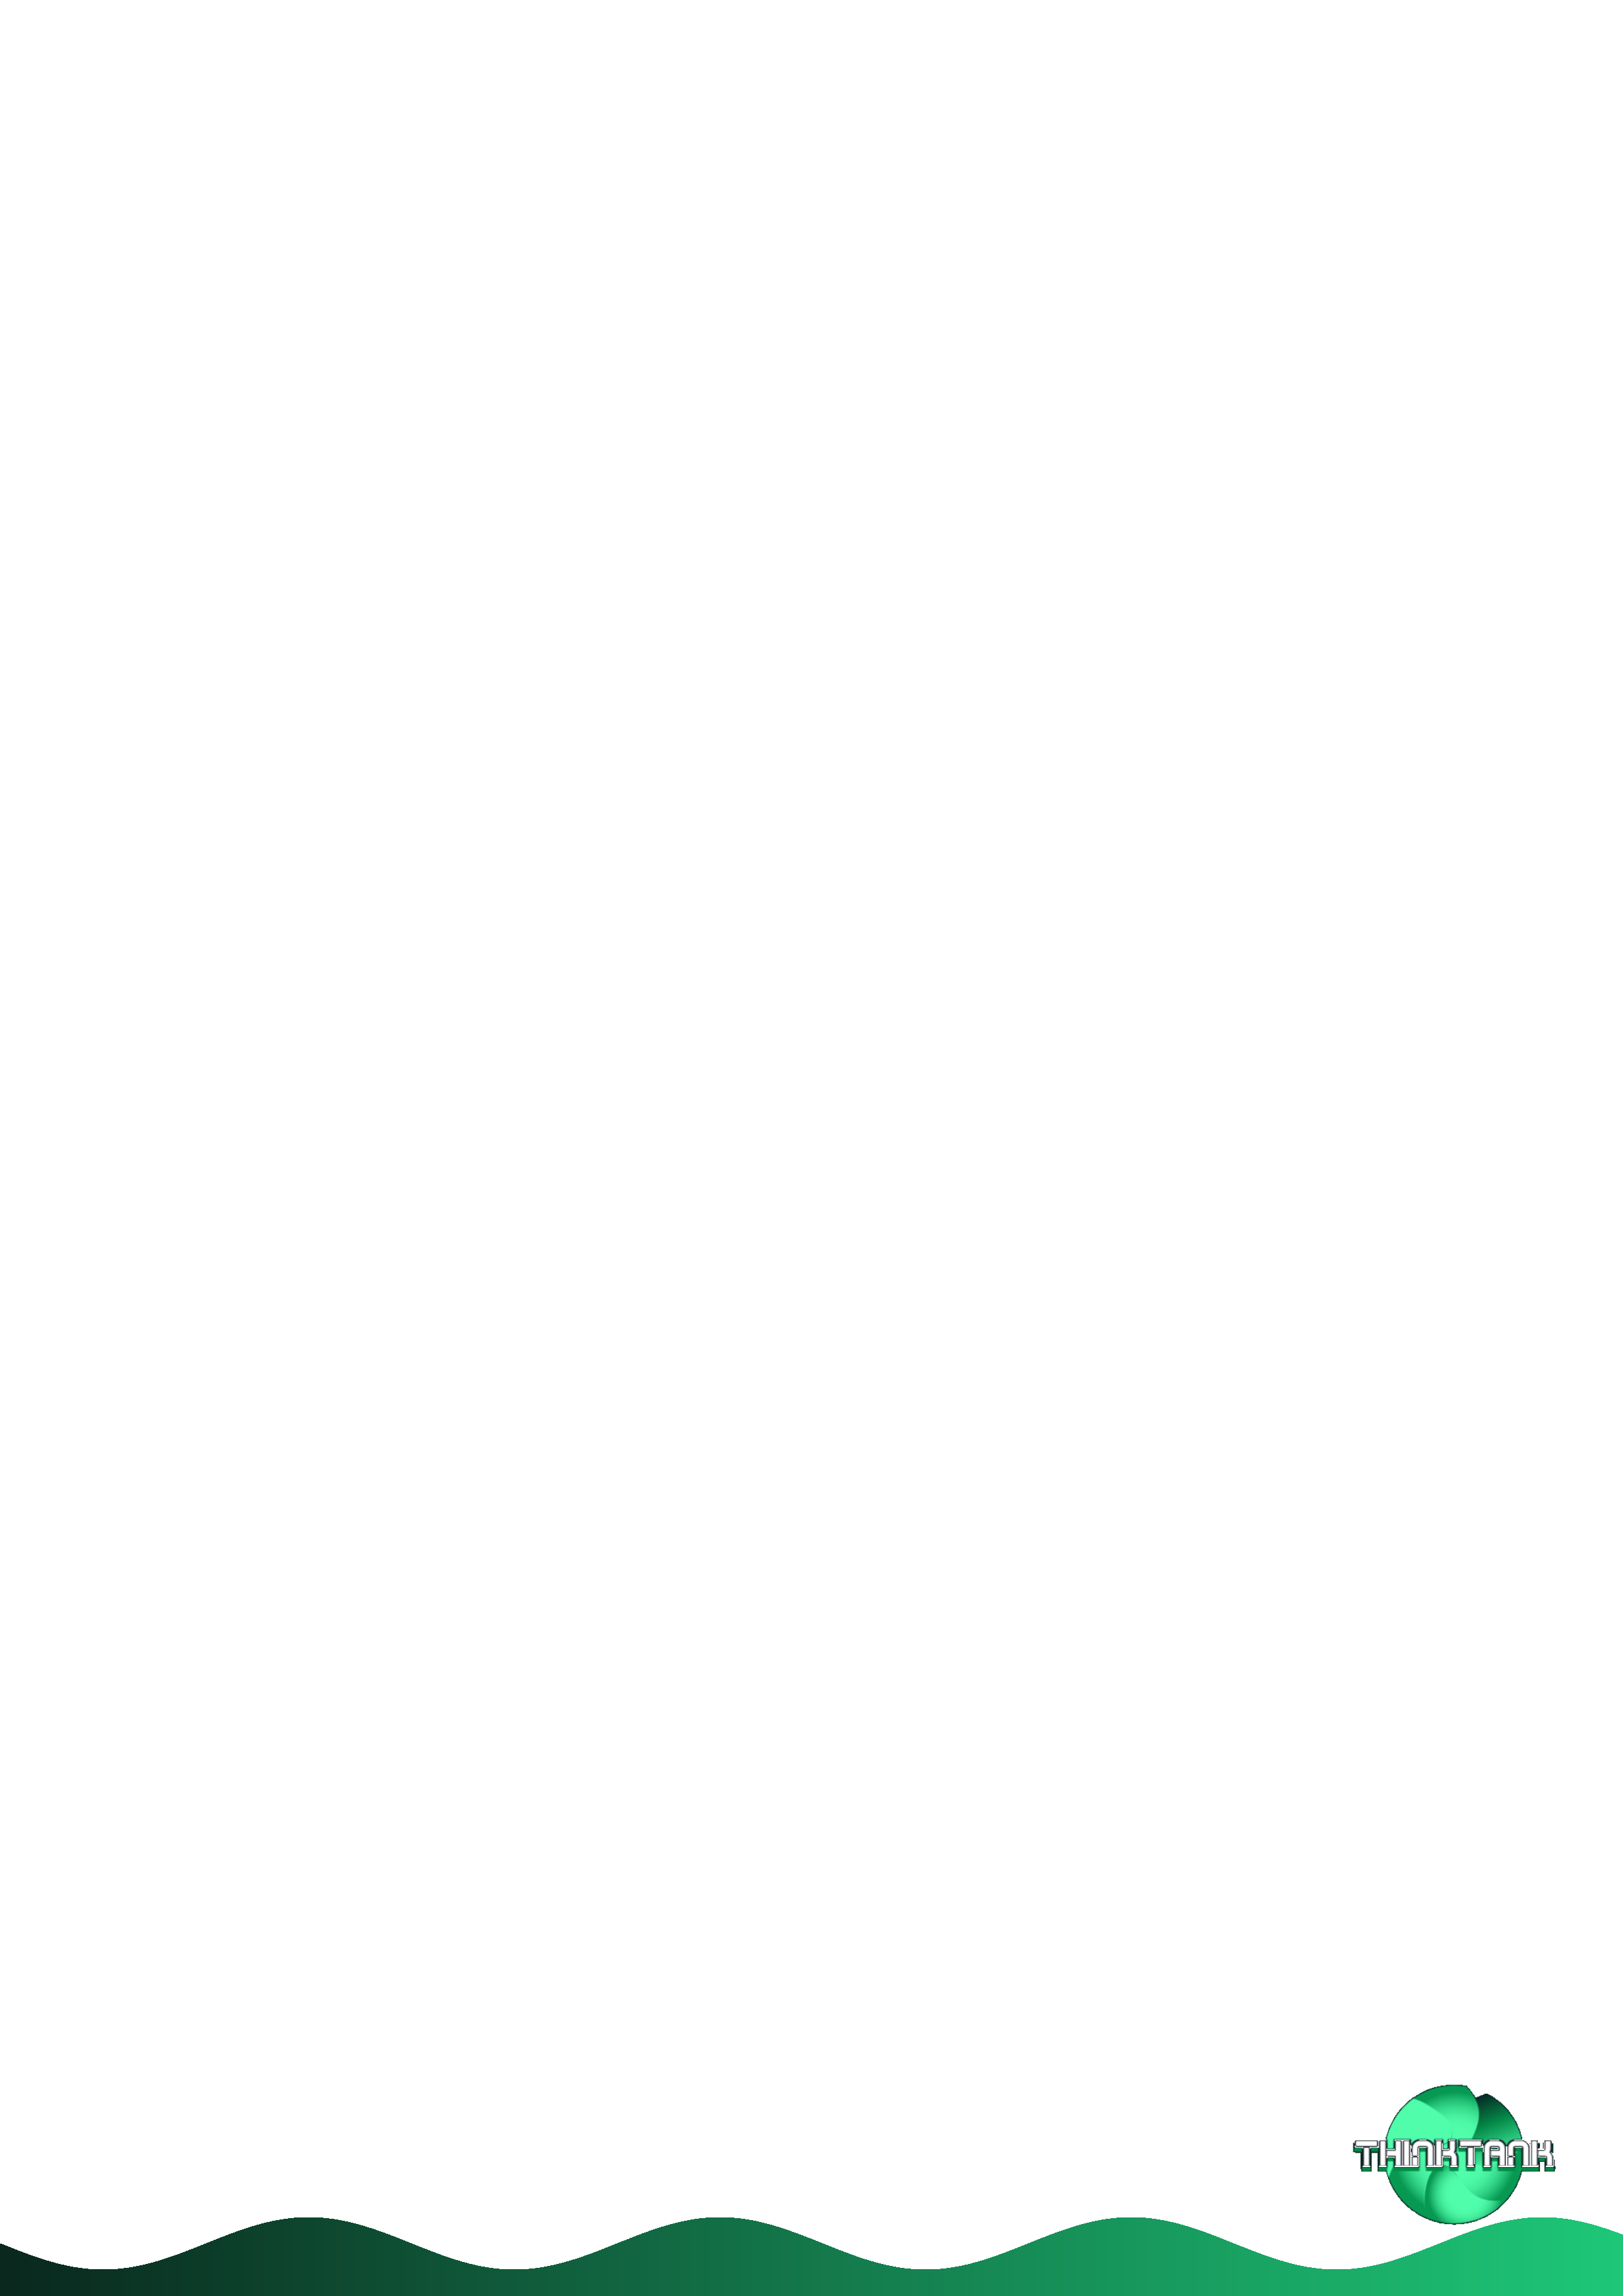

In [5]:
html=snapshot.values.get('pdf_html')
print(html)

In [6]:
import base64

def save_pdf_from_base64(pdf_base64: str, output_path: str = "output.pdf"):
    pdf_bytes = base64.b64decode(pdf_base64)
    
    with open(output_path, "wb") as f:
        f.write(pdf_bytes)

    print(f"PDF saved at {output_path}")

output="D:\After January\ThinkTank\Conversation_summary.pdf"
save_pdf_from_base64(pdf_base64=pdf_base64, output_path=output)

PDF saved at D:\After January\ThinkTank\Conversation_summary.pdf


<>:11: SyntaxWarning: invalid escape sequence '\A'
<>:11: SyntaxWarning: invalid escape sequence '\A'
C:\Users\soumi\AppData\Local\Temp\ipykernel_23400\3073011111.py:11: SyntaxWarning: invalid escape sequence '\A'
  output="D:\After January\ThinkTank\Conversation_summary.pdf"


In [ ]:
from typing import TypedDict, Annotated, cast
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage, AIMessage, ToolMessage, SystemMessage
from backend.Agents.Common_State import State
from langgraph.types import Command, interrupt
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from datetime import datetime
import pdfkit
import shutil
import base64
import uuid
import os
import json
load_dotenv()

OPENAI_API_KEY=os.getenv('OPENAI_API_KEY')

llm=ChatOpenAI(api_key=OPENAI_API_KEY, model='gpt-4o-mini')

from pydantic import BaseModel, Field
from typing import List

class ActionItem(BaseModel):
    task: str
    responsible: str
    priority: str  # High / Medium / Low

class ChartData(BaseModel):
    label: str
    value: int  # percentage or count

class Insight(BaseModel):
    title: str                          = Field(description="Short punchy report title")
    tagline: str                        = Field(description="One line subtitle")
    final_decision: str                 = Field(description="What was ultimately concluded")
    key_ideas: List[str]                = Field(description="3-5 core ideas from the conversation")
    action_items: List[ActionItem]      = Field(description="Concrete tasks with owner and priority")
    risks: List[str]                    = Field(description="Risks and unresolved questions")
    insights: List[str]                 = Field(description="Key learnings and principles")
    agreements: List[str]               = Field(description="What was agreed upon")
    evolution: str                      = Field(description="How the conversation progressed")
    highlight_stat_1: ChartData         = Field(description="A key metric or percentage from the conversation e.g. 60% agreement")
    highlight_stat_2: ChartData         = Field(description="Another key metric or percentage")
    countdown_items: List[str]          = Field(description="4 sequential steps or phases derived from the action plan")

def extract_insights(state: State) -> Insight:
    structured_llm = llm.with_structured_output(Insight)
    response = structured_llm.invoke([
        SystemMessage(content="Extract structured insights from this conversation. Be concise and data-driven."),
        HumanMessage(content=conversation_text)
    ])
    return response


class Get_Html(BaseModel):
    html: str = Field(
        description=(
            "A complete, valid HTML document starting with <!DOCTYPE html>. "
            "Must contain all CSS inline or in a <style> block. "
            "Do NOT wrap in markdown code fences. "
            "Use BG_IMAGE_PLACEHOLDER as the CSS background-image value. "
            "The document must be directly renderable by wkhtmltopdf."
        )
    )

def image_to_base64(image_path: str) -> str:
    ext = os.path.splitext(image_path)[1].replace('.', '')
    with open(image_path, 'rb') as f:
        encoded = base64.b64encode(f.read()).decode('utf-8')
    return f"data:image/{ext};base64,{encoded}"


def Report(conversation : State, image_path : str='./pdf_image.png'):
    
    LLM_instruction = conversation['LLM_instruction']
    
    Last_Output=conversation.get('Last_PDF_Agent_output', '')
    feedback=conversation.get('PDF_feedback', "")
    conversation_text=''
    for message in conversation['messages']:
        if isinstance(message, HumanMessage):
            role = "human"
        elif isinstance(message, AIMessage):
            role = "assistant"
        elif isinstance(message, SystemMessage):
            role = "system"
        elif isinstance(message, ToolMessage):
            role = "tool"
        else:
            role = "unknown"
            
        conversation_text += f"{role}: {message.content}\n\n"

    image_b64=image_to_base64(image_path=image_path)

    instruction=f'''
You are an expert analyst and report generator.

Your task is to read a conversation between participants (which may include brainstorming, discussion, or idea exploration) and convert it into a structured, insight-rich report — NOT just a summary.

You must extract meaningful conclusions, reasoning, and actionable insights, then generate a clean HTML document that will later be converted into a PDF.
------------------------
FEEDBACK
------------------------
If there was a previous generation for this same task which was not satisfactory to the user, a feedback has been provided
Feedback : {feedback} for output : {Last_Output}
If the feedback is empty ignore it
------------------------
INPUT
------------------------
You will be given:
1. A list of messages (conversation)

------------------------
PART 1 — ANALYSIS
------------------------

Carefully analyze the conversation and extract:

1. Final Decision(s)
   - What was ultimately concluded?

2. Key Ideas & Concepts
   - Core idea
   - Supporting ideas
   - Variations explored

3. Argument Mapping
   - Main claims
   - Supporting reasoning
   - Counterarguments (if any)

4. Action Plan
   - Tasks
   - Responsible person (if mentioned)
   - Priority (High/Medium/Low)

5. Insights & Learnings
   - General principles or lessons derived

6. Risks & Gaps
   - Missing considerations
   - Potential risks
   - Unresolved questions

7. Agreements & Disagreements
   - What participants agreed on
   - What remained debated

8. Evolution of Thought (optional but preferred)
   - How the discussion progressed step-by-step

IMPORTANT RULES:
- Do NOT summarize line-by-line
- Focus on high-value insights and structure
- Be concise but meaningful
- Do NOT include raw conversation text unless necessary

------------------------
PART 2 — HTML GENERATION
------------------------

Generate a COMPLETE HTML document that presents the above analysis as a professional report.

STRICT REQUIREMENTS:

BACKGROUND IMAGE:
- Do NOT generate or include any image data yourself
- For the background, use this exact placeholder as the CSS value:
  background-image: BG_IMAGE_PLACEHOLDER;
- Apply it to a position:fixed full-page div with these styles:
  position: fixed; top: 0; left: 0; width: 794px; height: 100%;
  background-size: cover; background-repeat: no-repeat;
  background-position: center; z-index: -1;

- Page layout:
  - A4 width: 794px
  - Allow natural vertical flow (no fixed height)

- Spacing constraints:
  - Leave at least 80px space at the TOP (no content there)
  - Leave at least 80px space at the BOTTOM

- Add a semi-transparent overlay behind text to ensure readability over the background

- Typography:
  - Clean, modern, professional
  - Clear section hierarchy (headings, subheadings)

- Structure the report using sections:
  - Title (e.g., "Conversation Insight Report")
  - Date / metadata
  - Each analysis section clearly separated

- Use:
  - Headings (h1, h2, h3)
  - Bullet points where appropriate
  - Clean spacing and alignment

- The HTML must be directly usable with PDF tools (like wkhtmltopdf)

------------------------
OUTPUT RULES
------------------------

- Return ONLY valid HTML
- Do NOT include explanations
- Do NOT include markdown
- Do NOT include JSON
- Do NOT include any base64 image data
- Output must start with <!DOCTYPE html>

------------------------
GOAL
------------------------

Transform an unstructured conversation into:
→ a decision-ready report  
→ visually clean PDF-ready HTML  
→ insight-rich, structured output  

This is not summarization — this is intelligent analysis + presentation.
'''
    structure_llm=llm.with_structured_output(Get_Html)
    response=structure_llm.invoke([SystemMessage(content=instruction), AIMessage(content=LLM_instruction), HumanMessage(content=conversation_text)])
    html = response.html

    image_b64 = image_to_base64(image_path)
    html = html.replace("BG_IMAGE_PLACEHOLDER", f"url('{image_b64}')")


    options = {
        'page-size': 'A4',
        'margin-top': '0',
        'margin-right': '0',
        'margin-bottom': '0',
        'margin-left': '0',
        'encoding': 'UTF-8',
        'enable-local-file-access': '',
    }

    wkhtmltopdf_path = (
        os.getenv('WKHTMLTOPDF_PATH') or
        shutil.which('wkhtmltopdf') or
        r'C:\Program Files\wkhtmltopdf\bin\wkhtmltopdf.exe'
    )

    if wkhtmltopdf_path:
        config = pdfkit.configuration(wkhtmltopdf=wkhtmltopdf_path)
    else:
        config = None  # fallback (will still fail if not installed)

    pdf = cast(
        bytes,
        pdfkit.from_string(
            input=html,
            output_path=False,
            options=options,
            configuration=config))


    return pdf, html


def PDF_Agent(state: State):
    pdf_bytes, html = Report(conversation=state)
    pdf_base64 = base64.b64encode(pdf_bytes).decode("utf-8")
    return {
        "pdf_bytes": pdf_bytes,
        "pdf_base64": pdf_base64,
        "pdf_html" : html,
        "messages": [
            AIMessage(content="PDF generated. Please review.")
        ],
        'Last_PDF_Agent_output': html
        }


def review_pdf(state: State):
    response = interrupt({
        "type": "Review PDF",
        "pdf": state["pdf_base64"]
    })

    if isinstance(response, dict):
        decision = response.get("decision")
        feedback = response.get("feedback")
    else:
        decision = response
        feedback = None

    if decision == "approve":
        return Command(goto=END, update={'Last_PDF_Agent_output': None, 'pdf_bytes': None, 'pdf_feedback' : None})
    
    return Command(
        goto="PDF_Agent",
        update={"PDF_feedback": feedback}
    )


In [1]:
import requests
import os
from dotenv import load_dotenv

load_dotenv()

API_KEY = os.getenv('TRELLO_API')
TOKEN = os.getenv('TRELLO_TOKEN')

def create_board(name):
    url = "https://api.trello.com/1/boards/"
    
    params = {
        "name": name,
        "defaultLists": "true",
        "key": API_KEY,
        "token": TOKEN
    }

    response = requests.post(url, params=params)
    return response.json()


board = create_board("AI Project")
print(board)

{'id': '69cf94034149c2a00d877438', 'name': 'AI Project', 'desc': '', 'descData': None, 'closed': False, 'idOrganization': '69cf83b089de25c062f0502c', 'idEnterprise': None, 'pinned': False, 'url': 'https://trello.com/b/0UKOD5vi/ai-project', 'shortUrl': 'https://trello.com/b/0UKOD5vi', 'prefs': {'permissionLevel': 'private', 'hideVotes': False, 'voting': 'disabled', 'comments': 'members', 'invitations': 'members', 'selfJoin': True, 'cardCovers': True, 'showCompleteStatus': True, 'cardCounts': False, 'isTemplate': False, 'cardAging': 'regular', 'calendarFeedEnabled': False, 'hiddenPluginBoardButtons': [], 'switcherViews': [{'viewType': 'Board', 'enabled': True}, {'viewType': 'Table', 'enabled': True}, {'viewType': 'Calendar', 'enabled': False}, {'viewType': 'Dashboard', 'enabled': False}, {'viewType': 'Timeline', 'enabled': False}, {'viewType': 'Map', 'enabled': False}], 'autoArchive': None, 'background': 'blue', 'backgroundColor': '#0079BF', 'backgroundDarkColor': None, 'backgroundImage'

In [7]:
import requests
API_KEY = os.getenv('TRELLO_API')
TOKEN = os.getenv('TRELLO_TOKEN')

def get_boards():
    url = "https://api.trello.com/1/members/me/boards"
    
    params = {
        "key": API_KEY,
        "token": TOKEN
    }

    response = requests.get(url, params=params)
    return response.json()

a=get_boards()
print(a)

[{'id': '69cf94034149c2a00d877438', 'nodeId': 'ari:cloud:trello::board/workspace/69cf83b089de25c062f0502c/69cf94034149c2a00d877438', 'name': 'AI Project', 'desc': '', 'descData': None, 'closed': False, 'creationMethod': 'automatic', 'creationMethodError': None, 'creationMethodLoadingStartedAt': None, 'dateClosed': None, 'idOrganization': '69cf83b089de25c062f0502c', 'idEnterprise': None, 'limits': {'attachments': {'perBoard': {'status': 'ok', 'disableAt': 36000, 'warnAt': 28800}, 'perCard': {'status': 'ok', 'disableAt': 1000, 'warnAt': 800}}, 'boards': {'totalMembersPerBoard': {'status': 'ok', 'disableAt': 1600, 'warnAt': 1280}, 'totalAccessRequestsPerBoard': {'status': 'ok', 'disableAt': 4000, 'warnAt': 3200}}, 'cards': {'openPerBoard': {'status': 'ok', 'disableAt': 5000, 'warnAt': 4000}, 'openPerList': {'status': 'ok', 'disableAt': 5000, 'warnAt': 4000}, 'totalPerBoard': {'status': 'ok', 'disableAt': 2000000, 'warnAt': 1600000}, 'totalPerList': {'status': 'ok', 'disableAt': 1000000, '

In [ ]:
def create_list(board_id, list_name):
    url = "https://api.trello.com/1/lists"
    
    params = {
        "name": list_name,
        "idBoard": board_id,
        "key": API_KEY,
        "token": TOKEN
    }

    response = requests.post(url, params=params)
    return response.json()

a=create_list('69cf94034149c2a00d877438', 'Task Agent')
print(a)

def get_lists(board_id):
    url = f"https://api.trello.com/1/boards/{board_id}/lists"
    
    params = {
        "key": API_KEY,
        "token": TOKEN
    }

    response = requests.get(url, params=params)
    return response.json()


{'id': '69cf97021e5627a8d066ec8e', 'name': 'Task Agent', 'closed': False, 'color': None, 'idBoard': '69cf94034149c2a00d877438', 'pos': 140737488338944, 'type': None, 'datasource': {'filter': False}, 'limits': {}}


In [9]:
import requests

def create_card(list_id, title):
    url = "https://api.trello.com/1/cards"
    
    params = {
        "idList": list_id,
        "name": title,
        "key": API_KEY,
        "token": TOKEN
    }

    return requests.post(url, params=params).json()


# Example
card = create_card('69cf97021e5627a8d066ec8e', "Build API")
print(card)

{'id': '69cf98a416c9ec33283b5844', 'agent': {'name': None, 'conversationId': None}, 'badges': {'attachments': 0, 'fogbugz': '', 'checkItems': 0, 'checkItemsChecked': 0, 'checkItemsEarliestDue': None, 'comments': 0, 'description': False, 'due': None, 'dueComplete': False, 'lastUpdatedByAi': False, 'start': None, 'externalSource': None, 'attachmentsByType': {'trello': {'board': 0, 'card': 0}}, 'location': False, 'votes': 0, 'maliciousAttachments': 0, 'viewingMemberVoted': False, 'subscribed': False}, 'checkItemStates': [], 'closed': False, 'dueComplete': False, 'dateLastActivity': '2026-04-03T10:38:28.424Z', 'desc': '', 'descData': {'emoji': {}}, 'due': None, 'dueReminder': None, 'email': None, 'idBoard': '69cf94034149c2a00d877438', 'idChecklists': [], 'idList': '69cf97021e5627a8d066ec8e', 'idMembers': [], 'idMembersVoted': [], 'idShort': 1, 'idAttachmentCover': None, 'labels': [], 'idLabels': [], 'manualCoverAttachment': False, 'name': 'Build API', 'nodeId': 'ari:cloud:trello::card/work

In [ ]:

BASE_URL = "https://api.trello.com/1"

def create_checklist(card_id, checklist_name):
    url = f"{BASE_URL}/checklists"
    
    params = {
        "idCard": card_id,
        "name": checklist_name,
        "key": API_KEY,
        "token": TOKEN
    }

    response = requests.post(url, params=params)
    return response.json()

def add_checklist_item(checklist_id, item_name):
    url = f"{BASE_URL}/checklists/{checklist_id}/checkItems"
    
    params = {
        "name": item_name,
        "key": API_KEY,
        "token": TOKEN
    }

    response = requests.post(url, params=params)
    return response.json()

In [10]:
import requests


def assign_member(card_id, member_id):
    url = f"https://api.trello.com/1/cards/{card_id}/idMembers"
    
    params = {
        "value": member_id,
        "key": API_KEY,
        "token": TOKEN
    }

    response = requests.post(url, params=params)
    return response.json()


In [ ]:
import requests

API_KEY = "your_api_key"
TOKEN = "your_token"

def set_due_date(card_id, due_date):
    url = f"https://api.trello.com/1/cards/{card_id}"
    
    params = {
        "due": due_date,
        "key": API_KEY,
        "token": TOKEN
    }

    response = requests.put(url, params=params)
    return response.json()

{'id': '69cf98a416c9ec33283b5844', 'agent': {'name': None, 'conversationId': None}, 'badges': {'attachments': 0, 'fogbugz': '', 'checkItems': 0, 'checkItemsChecked': 0, 'checkItemsEarliestDue': None, 'comments': 0, 'description': False, 'due': None, 'dueComplete': False, 'lastUpdatedByAi': False, 'start': None, 'externalSource': None, 'attachmentsByType': {'trello': {'board': 0, 'card': 0}}, 'location': False, 'votes': 0, 'maliciousAttachments': 0, 'viewingMemberVoted': False, 'subscribed': False}, 'checkItemStates': [], 'closed': False, 'dueComplete': False, 'dateLastActivity': '2026-04-03T10:38:28.424Z', 'desc': '', 'descData': {'emoji': {}}, 'due': None, 'dueReminder': None, 'email': None, 'idBoard': '69cf94034149c2a00d877438', 'idChecklists': [], 'idList': '69cf97021e5627a8d066ec8e', 'idMembers': [], 'idMembersVoted': [], 'idShort': 1, 'idAttachmentCover': None, 'labels': [], 'idLabels': [], 'manualCoverAttachment': False, 'name': 'Build API', 'nodeId': 'ari:cloud:trello::card/work